In [1]:
using NonlinearEigenproblems, Plots
include("cheb4c.jl");
include("chebdif.jl");

In [2]:
module chebyshev_method

    using LinearAlgebra

    export chebyshev_D
    # Chebyshev compute D = differentiation matrix, x = Chebyshev grid

    function  chebyshev_D(N)

        if N==0
            D = 0;
            x = 1;
            return D, x
        else
            θ = range(0,length=N+1,stop=pi)
            x = reshape(-cos.(θ), N+1, 1)
            c = [2; ones(N-1, 1) ; 2] .* (-1) .^ (0:N)
            X = repeat(x, 1, N+1);
            dX = X - X';
            D = (c * (1 ./ c)') ./ (dX .+ I(N+1));   # off-diagonal entries
            D = D - diagm(vec(sum(D, dims=2)));      # diagonal entries
            return D, x
        end
    end
end

Main.chebyshev_method

In [4]:
using .chebyshev_method
N = 256;      # Number of interior points
Re = 2000;    # Reynolds number
ω  = 0.3;     # Input frequency
β  = 0.0;     # Spanwise wavenumber

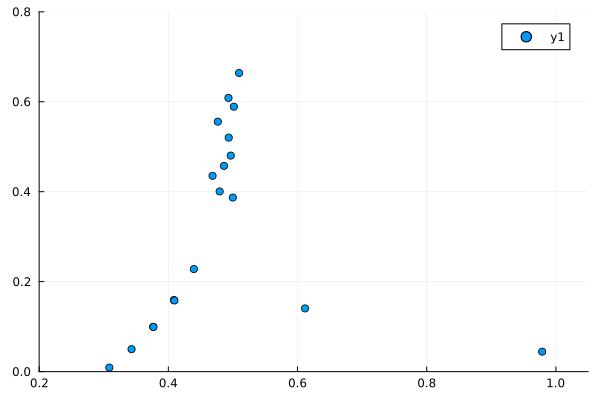

In [6]:
yF,DM = chebdif(N+2, 4);    
D2 = DM[2:N+1,2:N+1,2];              #D^2
yF,D4 = cheb4c(N+2);                 #D^4

# The base flow for Poiseuille plane flow
U   = 1 .-yF.^2;
Up  = -2*yF;
Upp = -2;

eye = Matrix{Float64}(I, N, N);  
A4 = [-eye/Re zeros(N,N);zeros(N,N) zeros(N,N)];
A3 = [-1im*diagm(0 => U) zeros(N,N);zeros(N,N) zeros(N,N)];
A2 = [(1im*ω-2β^2/Re)*eye+2D2/Re zeros(N,N);zeros(N,N) eye/Re];
A1 = [1im*(diagm(0 => U)*(D2-eye*β^2)-Upp*eye) zeros(N,N);zeros(N,N) 1im*diagm(0=>U)];
A0 = [2β^2*D2/Re-D4/Re-β^4*eye/Re+1im*ω*(β^2*eye-D2) zeros(N,N);1im*β*diagm(0 => Up) (-1im*ω+β^2/Re)*eye-D2/Re];
nep = PEP([A0,A1,A2,A3,A4]); #Create a PEP object
sc=100;
nep1 = shift_and_scale(nep,scale=sc);
mult_scale = norm(nep1.A[end]);
nep2 = PEP(nep1.A ./ mult_scale);
λ1,v1 = tiar(nep2,σ=0.006,v=ones(size(nep,1)),neigs=10,maxit=200,tol=1e-14);
λ2,v2 = tiar(nep2,σ=0.005+0.005im,v=ones(size(nep,1)),neigs=10,maxit=200,tol=1e-14);
λtotal = [λ1;λ2];
λ_orig = sc*λtotal
plot(real.(λ_orig),imag.(λ_orig),seriestype=:scatter,xaxis=[0.2,1.05],yaxis=[0,0.8])

In [8]:
data=[real(λ_orig) imag(λ_orig)]
using DelimitedFiles
writedlm("n=40.dat",data ,'\t')

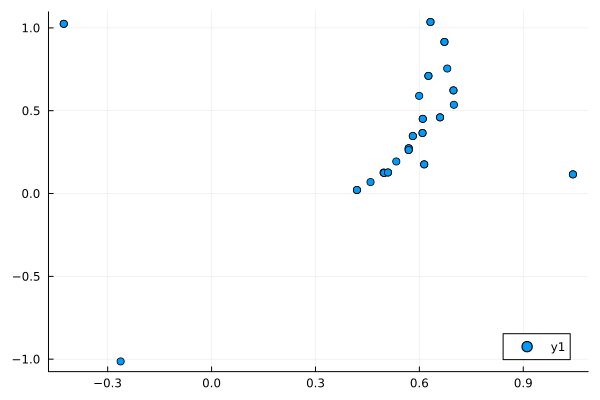

In [6]:
plot(real.(λ_orig),imag.(λ_orig),seriestype=:scatter)